<a href="https://colab.research.google.com/github/MedhatElhawy/solvingNotbooks/blob/main/Solution_week8_sequence_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter, defaultdict
from datasets import load_dataset
import random
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('dark_background')
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu


In [82]:
# note in here how i didn't give you the file but i uploaded it to my google drive
# so that you can download them to your colab machine
# glove_path = 'https://drive.google.com/file/d/1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q/view?usp=sharing'
import gdown

# Google Drive file ID from my link
file_id = "1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q"
url = f"https://drive.google.com/uc?id={file_id}"

output = "glove_vectors.txt"
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q
From (redirected): https://drive.google.com/uc?id=1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q&confirm=t&uuid=11bd1934-59c7-4a76-9111-826eddc62ef3
To: /content/glove_vectors.txt
100%|██████████| 1.68G/1.68G [00:25<00:00, 67.0MB/s]


'glove_vectors.txt'

---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #8b0000; padding: 15px; border-radius: 10px;">

# Part 2: Many-to-One (SMS Spam Classification) - PRACTICE

</div>

**Now it's YOUR turn!**

**Task:** Classify SMS messages as **spam** (1) or **not spam** (0)

**Dataset:** SMS Spam Collection (5574 real text messages)

**What you need to do:**

1. Build vocabulary from SMS dataset
2. Create SpamDataset class (many-to-one, like sentiment anlaysis problems)
3. Adapt 4 RNN models for binary classification
4. Train all models and compare
5. Visualize results

**Hints:**

- Use the same structure as Food NER but change to many-to-one
- For many-to-one: Use final hidden state (not all outputs)
- GloVe embeddings are already loaded!
- Follow the patterns from the Food NER example above

## Load SMS Spam Dataset


In [83]:
# Load SMS Spam dataset
print('Loading SMS Spam dataset...')
sms_data = load_dataset('sms_spam', split='train')

# Shuffle and split
sms_data = sms_data.shuffle(seed=42)
split_idx = int(0.8 * len(sms_data))

train_sms = sms_data.select(range(split_idx))
test_sms = sms_data.select(range(split_idx, len(sms_data)))

print(f'\nDataset: SMS Spam Collection')
print(f'Train: {len(train_sms)} messages')
print(f'Test: {len(test_sms)} messages')
print(f'\nClasses: 0=Not Spam, 1=Spam')

print(f'\nSample messages:')
print(f'Message: {train_sms[0]["sms"]}')
print(f'Label: {train_sms[0]["label"]}')
print(f'\nMessage: {train_sms[10]["sms"]}')
print(f'Label: {train_sms[10]["label"]}')

Loading SMS Spam dataset...

Dataset: SMS Spam Collection
Train: 4459 messages
Test: 1115 messages

Classes: 0=Not Spam, 1=Spam

Sample messages:
Message: sports fans - get the latest sports news str* 2 ur mobile 1 wk FREE PLUS a FREE TONE Txt SPORT ON to 8007 www.getzed.co.uk 0870141701216+ norm 4txt/120p 

Label: 1

Message: Cramps stopped. Going back to sleep

Label: 0


## TODO 1: Build Vocabulary for SMS Data

Create a vocabulary dictionary from the SMS training data.

**Requirements:**

- Include `<PAD>` and `<UNK>` tokens
- Add words appearing at least 2 times
- Store result in `sms_vocab` dictionary

**Hint:** Follow the same pattern as Food NER vocabulary building!


In [84]:
# TODO: Build vocabulary from SMS training data

# Build vocabulary from training data
sms_vocab = {'<PAD>': 0, '<UNK>': 1}
word_counts = Counter()

for text in train_sms:
    words = text['sms'].lower().split()
    word_counts.update(words)

for word, count in word_counts.items():
    if count >= 2 and word not in sms_vocab:
        sms_vocab[word] = len(sms_vocab)

print(f'SMS Vocabulary size: {len(sms_vocab)}')
print(f'Sample vocab: {list(sms_vocab.items())[:10]}')

SMS Vocabulary size: 4754
Sample vocab: [('<PAD>', 0), ('<UNK>', 1), ('sports', 2), ('-', 3), ('get', 4), ('the', 5), ('latest', 6), ('news', 7), ('2', 8), ('ur', 9)]


In [85]:
# HIDDEN TESTS for vocabulary

In [86]:
# Load pre-trained GloVe embeddings
# GloVe (Global Vectors) trained on Wikipedia + Gigaword corpus
EMBEDDING_DIM = 100

print("Loading GloVe embeddings...")


#glove_path = 'glove.2024.wikigiga.100d\wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt'
glove_path = 'glove_vectors.txt'
# Load GloVe vectors
glove_vectors = {}
skipped = 0

with open(glove_path, 'r', encoding='utf-8') as f:
    for line_num, line in enumerate(f):
        try:
            values = line.rstrip().split(' ')
            word = values[0]
            vector = np.array(values[1:], dtype='float32')

            # Only add if vector has correct dimension
            if len(vector) == EMBEDDING_DIM:
                glove_vectors[word] = vector
            else:
                skipped += 1
        except (ValueError, IndexError):
            skipped += 1
            continue

        if (line_num + 1) % 100000 == 0:
            print(f"  Processed {line_num + 1:,} lines...")

print(f"\nLoaded {len(glove_vectors):,} GloVe vectors")
if skipped > 0:
    print(f"Skipped {skipped:,} malformed lines")

Loading GloVe embeddings...
  Processed 100,000 lines...
  Processed 200,000 lines...
  Processed 300,000 lines...
  Processed 400,000 lines...
  Processed 500,000 lines...
  Processed 600,000 lines...
  Processed 700,000 lines...
  Processed 800,000 lines...
  Processed 900,000 lines...
  Processed 1,000,000 lines...
  Processed 1,100,000 lines...
  Processed 1,200,000 lines...

Loaded 1,291,147 GloVe vectors


In [87]:
# Create SMS embedding matrix (using same GloVe vectors)
sms_embedding_matrix = np.random.randn(len(sms_vocab), EMBEDDING_DIM).astype('float32') * 0.01
sms_embedding_matrix[sms_vocab['<PAD>']] = np.zeros(EMBEDDING_DIM)
found_count_sms = 0
for word, idx in sms_vocab.items():
    if word in glove_vectors:
        sms_embedding_matrix[idx] = glove_vectors[word]
        found_count_sms += 1

print(f'SMS Embedding matrix shape: {sms_embedding_matrix.shape}')
print(f'Found GloVe vectors for {found_count_sms}/{len(sms_vocab)} words ({100*found_count_sms/len(sms_vocab):.1f}%)')

SMS Embedding matrix shape: (4754, 100)
Found GloVe vectors for 2831/4754 words (59.5%)


## TODO 2: Create SpamDataset Class

Create a PyTorch Dataset class for SMS spam classification.

**Requirements:**

- Inherit from `torch.utils.data.Dataset`
- Implement `__init__`, `__len__`, `__getitem__`
- Convert SMS text to word IDs
- Return (text_tensor, label_tensor)
- This is **many-to-one** (entire message → single label)

**Hint:** Very similar to FoodNERDataset but labels are scalars, not sequences!


In [88]:
# TODO: Create SpamDataset class
class SpamDataset(Dataset):

    def __init__(self, data, vocab):
        self.data = data
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]['sms'].lower().split()
        label = self.data[idx]['label']

        word_ids = [self.vocab.get(word, self.vocab['<UNK>']) for word in text]

        return torch.tensor(word_ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)


# Collate function for spam data
def spam_collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=sms_vocab['<PAD>'])
    labels = torch.tensor(labels, dtype=torch.long)
    return padded_texts, labels, lengths


# Create datasets
train_spam_dataset = SpamDataset(train_sms, sms_vocab)
test_spam_dataset = SpamDataset(test_sms, sms_vocab)

train_spam_loader = DataLoader(train_spam_dataset, batch_size=32, shuffle=True, collate_fn=spam_collate_fn)
test_spam_loader = DataLoader(test_spam_dataset, batch_size=32, shuffle=False, collate_fn=spam_collate_fn)

print(f'Train batches: {len(train_spam_loader)}')
print(f'Test batches: {len(test_spam_loader)}')

Train batches: 140
Test batches: 35


In [89]:
# HIDDEN TESTS for SpamDataset

## TODO 3: Implement 4 RNN Models for Spam Classification

Adapt the 4 RNN models for **binary spam classification (many-to-one)**.

**Key differences from Food NER:**

- Use **final hidden state** (not all outputs)
- Output dimension = 2 (spam vs not-spam)
- For BiLSTM: Concatenate forward and backward final hidden states

**Models to implement:**

1. VanillaRNNSpam
2. GRUSpam
3. LSTMSpam
4. BiLSTMSpam

**Hint:** Use `pack_padded_sequence` and extract final hidden states!


In [90]:
# TODO: Implement 4 RNN models for spam classification

from torch.nn.utils.rnn import pack_padded_sequence

# 1. Vanilla RNN Model (Packed)
class VanillaRNNSpam(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, hidden = self.rnn(packed_embedded)
        predictions = self.fc(hidden[-1])
        return predictions

# 2. GRU Model (Packed)
class GRUSpam(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, hidden = self.gru(packed_embedded)
        predictions = self.fc(hidden[-1])
        return predictions

# 3. LSTM Model (Packed)
class LSTMSpam(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x, lengths):
        embedded = self.embedding(x)

        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)

        predictions = self.fc(hidden[-1])
        return predictions

# 4. BiLSTM Model (Packed)
class BiLSTMSpam(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x, lengths):
        embedded = self.embedding(x)

        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        cat_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        predictions = self.fc(cat_hidden)
        return predictions

print('All 4 spam classification models defined!')

All 4 spam classification models defined!


In [91]:
# HIDDEN TESTS for spam models

## Training and Evaluation Functions



In [92]:
def train_spam_model(model, train_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for texts, labels, lengths in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            predictions = model(texts, lengths)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    return losses


def evaluate_spam_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels, lengths in test_loader:
            texts = texts.to(device)
            predictions = model(texts, lengths)
            predicted_labels = torch.argmax(predictions, dim=1).cpu().numpy()
            all_preds.extend(predicted_labels)
            all_labels.extend(labels.numpy())
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy


print('Training functions ready!')

Training functions ready!


## Train All 4 Spam Models

Now train all 4 models and compare their performance!


In [93]:
# Train all 4 spam models
SPAM_HIDDEN_DIM = 128
SPAM_EPOCHS = 10
SPAM_LR = 0.001

spam_results = {}

# Vanilla RNN
print('='*60)
print('Training Vanilla RNN for Spam...')
print('='*60)
rnn_spam = VanillaRNNSpam(len(sms_vocab), EMBEDDING_DIM, SPAM_HIDDEN_DIM, sms_embedding_matrix)
rnn_spam_losses = train_spam_model(rnn_spam, train_spam_loader, epochs=SPAM_EPOCHS, lr=SPAM_LR)
rnn_spam_acc = evaluate_spam_model(rnn_spam, test_spam_loader)
spam_results['Vanilla RNN'] = {'losses': rnn_spam_losses, 'accuracy': rnn_spam_acc}
print(f'\nVanilla RNN Spam Accuracy: {rnn_spam_acc:.4f}\n')

# GRU
print('='*60)
print('Training GRU for Spam...')
print('='*60)
gru_spam = GRUSpam(len(sms_vocab), EMBEDDING_DIM, SPAM_HIDDEN_DIM, sms_embedding_matrix)
gru_spam_losses = train_spam_model(gru_spam, train_spam_loader, epochs=SPAM_EPOCHS, lr=SPAM_LR)
gru_spam_acc = evaluate_spam_model(gru_spam, test_spam_loader)
spam_results['GRU'] = {'losses': gru_spam_losses, 'accuracy': gru_spam_acc}
print(f'\nGRU Spam Accuracy: {gru_spam_acc:.4f}\n')

# LSTM
print('='*60)
print('Training LSTM for Spam...')
print('='*60)
lstm_spam = LSTMSpam(len(sms_vocab), EMBEDDING_DIM, SPAM_HIDDEN_DIM, sms_embedding_matrix)
lstm_spam_losses = train_spam_model(lstm_spam, train_spam_loader, epochs=SPAM_EPOCHS, lr=SPAM_LR)
lstm_spam_acc = evaluate_spam_model(lstm_spam, test_spam_loader)
spam_results['LSTM'] = {'losses': lstm_spam_losses, 'accuracy': lstm_spam_acc}
print(f'\nLSTM Spam Accuracy: {lstm_spam_acc:.4f}\n')

# BiLSTM
print('='*60)
print('Training BiLSTM for Spam...')
print('='*60)
bilstm_spam = BiLSTMSpam(len(sms_vocab), EMBEDDING_DIM, SPAM_HIDDEN_DIM, sms_embedding_matrix)
bilstm_spam_losses = train_spam_model(bilstm_spam, train_spam_loader, epochs=SPAM_EPOCHS, lr=SPAM_LR)
bilstm_spam_acc = evaluate_spam_model(bilstm_spam, test_spam_loader)
spam_results['BiLSTM'] = {'losses': bilstm_spam_losses, 'accuracy': bilstm_spam_acc}
print(f'\nBiLSTM Spam Accuracy: {bilstm_spam_acc:.4f}\n')

Training Vanilla RNN for Spam...
Epoch 1/10, Loss: 0.2000
Epoch 2/10, Loss: 0.0954
Epoch 3/10, Loss: 0.0598
Epoch 4/10, Loss: 0.0430
Epoch 5/10, Loss: 0.0263
Epoch 6/10, Loss: 0.0245
Epoch 7/10, Loss: 0.0124
Epoch 8/10, Loss: 0.0062
Epoch 9/10, Loss: 0.0107
Epoch 10/10, Loss: 0.0135

Vanilla RNN Spam Accuracy: 0.9812

Training GRU for Spam...
Epoch 1/10, Loss: 0.1924
Epoch 2/10, Loss: 0.0644
Epoch 3/10, Loss: 0.0416
Epoch 4/10, Loss: 0.0204
Epoch 5/10, Loss: 0.0140
Epoch 6/10, Loss: 0.0089
Epoch 7/10, Loss: 0.0044
Epoch 8/10, Loss: 0.0023
Epoch 9/10, Loss: 0.0015
Epoch 10/10, Loss: 0.0013

GRU Spam Accuracy: 0.9910

Training LSTM for Spam...
Epoch 1/10, Loss: 0.2143
Epoch 2/10, Loss: 0.0794
Epoch 3/10, Loss: 0.0480
Epoch 4/10, Loss: 0.0322
Epoch 5/10, Loss: 0.0163
Epoch 6/10, Loss: 0.0129
Epoch 7/10, Loss: 0.0085
Epoch 8/10, Loss: 0.0103
Epoch 9/10, Loss: 0.0091
Epoch 10/10, Loss: 0.0044

LSTM Spam Accuracy: 0.9901

Training BiLSTM for Spam...
Epoch 1/10, Loss: 0.1932
Epoch 2/10, Loss:

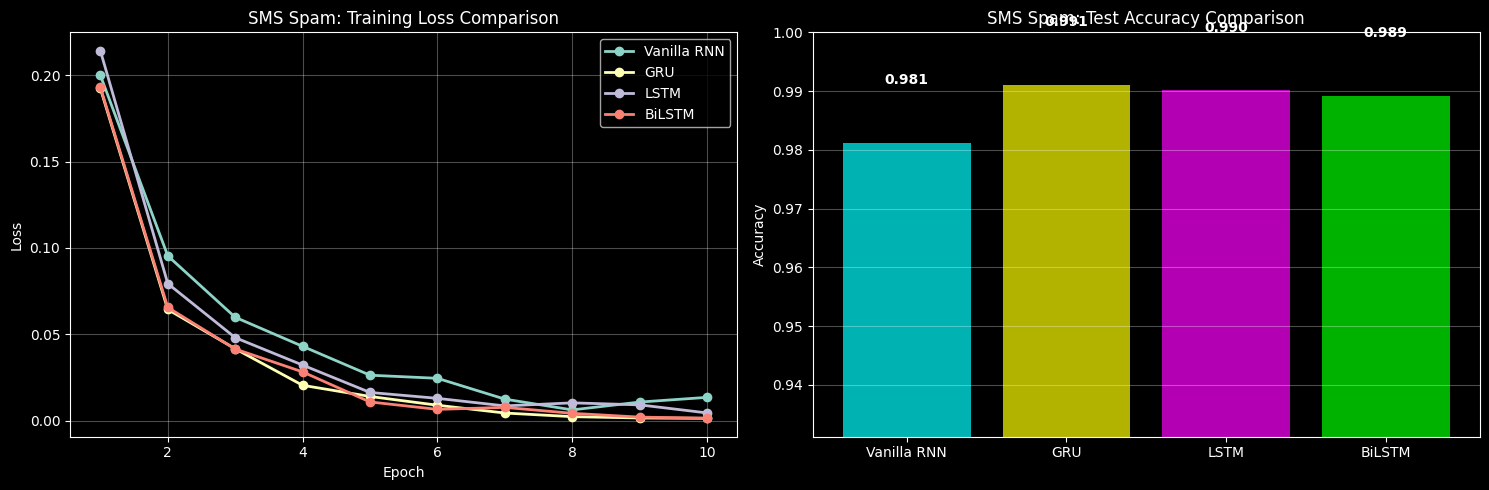

SMS SPAM RESULTS SUMMARY
Vanilla RNN     Accuracy: 0.9812
GRU             Accuracy: 0.9910
LSTM            Accuracy: 0.9901
BiLSTM          Accuracy: 0.9892


In [94]:
# Visualize spam results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training losses
for name, data in spam_results.items():
    ax1.plot(range(1, SPAM_EPOCHS+1), data['losses'], marker='o', label=name, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('SMS Spam: Training Loss Comparison')
ax1.legend()
ax1.grid(alpha=0.3)

# Test accuracies
models = list(spam_results.keys())
accuracies = [spam_results[m]['accuracy'] for m in models]
colors = ['cyan', 'yellow', 'magenta', 'lime']
ax2.bar(models, accuracies, color=colors, alpha=0.7)
ax2.set_ylabel('Accuracy')
ax2.set_title('SMS Spam: Test Accuracy Comparison')
ax2.set_ylim([min(accuracies) - 0.05, 1.0])
ax2.grid(alpha=0.3, axis='y')
for i, v in enumerate(accuracies):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('='*60)
print('SMS SPAM RESULTS SUMMARY')
print('='*60)
for name, data in spam_results.items():
    print(f"{name:15s} Accuracy: {data['accuracy']:.4f}")
print('='*60)